In [ ]:
!pip install -q transformers datasets accelerate scikit-learn seaborn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving opj_dataset.json to opj_dataset.json


BRISANJE DUPLIKATA - duplikati sa razlicitim sentimentom su rucno uklonjeni

In [ ]:
import json

DATA_PATH_TMP = "opj_dataset.json"
DATA_PATH = "opj_dataset_no_duplicates.json"

with open(DATA_PATH_TMP, "r", encoding="utf-8") as f:
    data = json.load(f)

seen = set()
unique_data = []

for item in data:
    text = item["tekst"]

    if text not in seen:
        seen.add(text)
        unique_data.append(item)

print("Broj unosa nakon uklanjanja duplikata:", len(unique_data))
print("Uklonjeno duplikata:", len(data) - len(unique_data)) #ocekivano 10

with open(DATA_PATH, "w", encoding="utf-8") as f:
    json.dump(unique_data, f, ensure_ascii=False, indent=2)

Broj unosa nakon uklanjanja duplikata: 2908
Uklonjeno duplikata: 10


UCITAVANJE DATASETA

In [ ]:
import json
import numpy as np

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def load_data(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    texts, labels = [], []
    for i, item in enumerate(data):
        if item["sentiment"] not in LABEL2ID:
            raise ValueError(f"Nepoznat sentiment na indeksu {i}: {item['sentiment']}")
        texts.append(item["tekst"])
        labels.append(LABEL2ID[item["sentiment"]])
    return np.array(texts, dtype=object), np.array(labels)

X, y = load_data(DATA_PATH)
print(f"Ukupno primera: {len(X)}")

unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {ID2LABEL[u]}: {c}")

Ukupno primera: 2908
  negative: 960
  neutral: 996
  positive: 952


PODESAVANJA

In [ ]:
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    get_linear_schedule_with_warmup,
)

MODEL_NAME = "classla/bcms-bertic"
DATA_PATH = "dataset.json"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

BROJ_FOLDOVA = 10
BROJ_EPOHA = 5
VELICINA_BATCHA = 16
MAKSIMALNA_DUZINA = 128
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Uredjaj:", device)


def set_seed(s):
    import random
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Uredjaj: cuda


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/231k [00:00<?, ?B/s]

LOADER

In [ ]:
def make_loader(texts, labels, shuffle):
    enc = tokenizer(
        list(texts), truncation=True, padding="max_length",
        max_length=MAKSIMALNA_DUZINA, return_tensors="pt",
    )
    ds = TensorDataset(
        enc["input_ids"], enc["attention_mask"],
        torch.tensor(labels, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=VELICINA_BATCHA, shuffle=shuffle)

FOLD - za fiksan broj epoha

In [ ]:
def fine_tune_fold(lr, X_tr, y_tr, X_te, y_te):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID,
    ).to(device)

    train_loader = make_loader(X_tr, y_tr, shuffle=True)
    test_loader = make_loader(X_te, y_te, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * BROJ_EPOHA
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.06 * total_steps), num_training_steps=total_steps,
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    model.train()
    for _ in range(BROJ_EPOHA):
        for ids, mask, yb in train_loader:
            ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss_fn(logits, yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for ids, mask, _ in test_loader:
            logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
            preds.extend(logits.argmax(-1).cpu().numpy().tolist())

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return preds

FUNKCIJA ZA TRENING I EVALUACIJU - za fiksan broj epoha

In [ ]:
def train_and_evaluate_cv(lr, n_folds=BROJ_FOLDOVA):
    set_seed(SEED)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    oof_preds = np.full(len(y), -1, dtype=int)

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        preds = fine_tune_fold(lr, X[train_idx], y[train_idx], X[test_idx], y[test_idx])
        oof_preds[test_idx] = preds

        f1_fold = f1_score(y[test_idx], preds, average="macro", zero_division=0)
        print(f"Fold {fold_idx}/{n_folds}: F1_macro = {f1_fold:.4f}")

    f1_final = f1_score(y, oof_preds, average="macro", zero_division=0)
    acc_final = accuracy_score(y, oof_preds)

    print(f"\n=== Krajnji rezultat (OOF, ceo dataset) ===")
    print(f"F1 macro: {f1_final:.4f}")
    print(f"Accuracy: {acc_final:.4f}\n")

    labels_order = list(LABEL2ID.keys())
    print(classification_report(y, oof_preds, target_names=labels_order, zero_division=0))

    cm = confusion_matrix(y, oof_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_order, yticklabels=labels_order)
    plt.xlabel("Predviđeno")
    plt.ylabel("Stvarno")
    plt.title(f"BERTić — LR={lr}, F1={f1_final:.2%}, Acc={acc_final:.2%}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_lr{lr}.png", dpi=150)
    plt.show()

    return {"f1_macro": f1_final, "accuracy": acc_final, "oof_preds": oof_preds, "confusion_matrix": cm}

LR = 2e-5

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1/10: F1_macro = 0.8273


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 9/10: F1_macro = 0.8720


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 10/10: F1_macro = 0.8141

=== Krajnji rezultat (OOF, ceo dataset) ===
F1 macro: 0.8291
Accuracy: 0.8287

              precision    recall  f1-score   support

    negative       0.88      0.88      0.88       960
     neutral       0.79      0.76      0.78       996
    positive       0.82      0.85      0.83       952

    accuracy                           0.83      2908
   macro avg       0.83      0.83      0.83      2908
weighted avg       0.83      0.83      0.83      2908



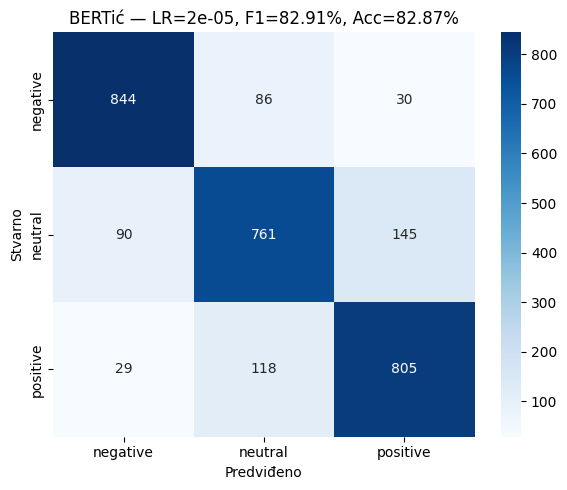

In [ ]:
rezultat = train_and_evaluate_cv(2e-5)

In [ ]:
print(rezultat)

{'f1_macro': 0.8290876901096782, 'accuracy': 0.828748280605227, 'oof_preds': array([2, 2, 2, ..., 1, 0, 2]), 'confusion_matrix': array([[844,  86,  30],
       [ 90, 761, 145],
       [ 29, 118, 805]])}


LOWERCASE

In [ ]:
def train_and_evaluate_cv_lowercase(lr, n_folds=BROJ_FOLDOVA):
    set_seed(SEED)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    oof_preds = np.full(len(y), -1, dtype=int)

    X_lower = np.array([t.lower() for t in X], dtype=object)

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_lower, y), start=1):
        preds = fine_tune_fold(lr, X_lower[train_idx], y[train_idx], X_lower[test_idx], y[test_idx])
        oof_preds[test_idx] = preds

        f1_fold = f1_score(y[test_idx], preds, average="macro", zero_division=0)
        print(f"Fold {fold_idx}/{n_folds}: F1_macro = {f1_fold:.4f}")

    f1_final = f1_score(y, oof_preds, average="macro", zero_division=0)
    acc_final = accuracy_score(y, oof_preds)

    print(f"\n=== Krajnji rezultat (OOF, ceo dataset) ===")
    print(f"F1 macro: {f1_final:.4f}")
    print(f"Accuracy: {acc_final:.4f}\n")

    labels_order = list(LABEL2ID.keys())
    print(classification_report(y, oof_preds, target_names=labels_order, zero_division=0))

    cm = confusion_matrix(y, oof_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_order, yticklabels=labels_order)
    plt.xlabel("Predviđeno")
    plt.ylabel("Stvarno")
    plt.title(f"BERTić — LR={lr}, F1={f1_final:.2%}, Acc={acc_final:.2%}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_lr{lr}.png", dpi=150)
    plt.show()

    return {"f1_macro": f1_final, "accuracy": acc_final, "oof_preds": oof_preds, "confusion_matrix": cm}

*LR* = 2e-5 LOWERCASE

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1/10: F1_macro = 0.8355


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 9/10: F1_macro = 0.8665


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 10/10: F1_macro = 0.7941

=== Krajnji rezultat (OOF, ceo dataset) ===
F1 macro: 0.8269
Accuracy: 0.8267

              precision    recall  f1-score   support

    negative       0.87      0.89      0.88       960
     neutral       0.79      0.76      0.78       996
    positive       0.83      0.83      0.83       952

    accuracy                           0.83      2908
   macro avg       0.83      0.83      0.83      2908
weighted avg       0.83      0.83      0.83      2908



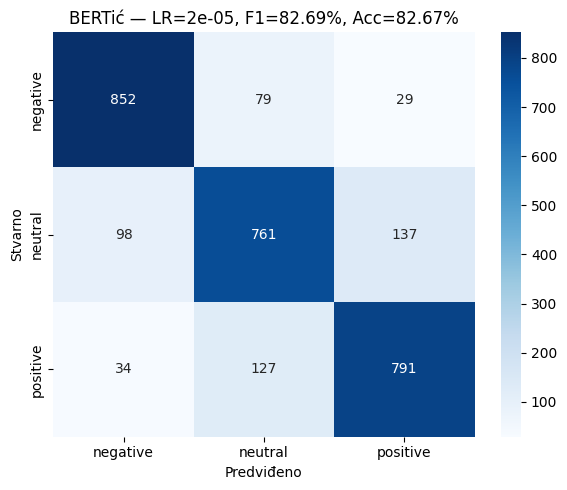

In [ ]:
rezultat = train_and_evaluate_cv_lowercase(2e-5)

**EPOHE**

In [ ]:
def train_and_evaluate_cv_best_epoch(lr, lowercase=False, n_folds=BROJ_FOLDOVA, epohe=BROJ_EPOHA):
    set_seed(SEED)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    X_used = np.array([t.lower() for t in X], dtype=object) if lowercase else X

    fold_f1 = np.zeros((n_folds, epohe))
    fold_acc = np.zeros((n_folds, epohe))
    oof = np.full((epohe, len(y)), -1, dtype=int)

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_used, y), start=1):
        X_tr, X_te = X_used[train_idx], X_used[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID,
        ).to(device)

        train_loader = make_loader(X_tr, y_tr, shuffle=True)
        test_loader = make_loader(X_te, y_te, shuffle=False)

        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        total_steps = len(train_loader) * epohe
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.06 * total_steps), num_training_steps=total_steps,
        )
        loss_fn = torch.nn.CrossEntropyLoss()

        for epoch in range(1, epohe + 1):
            model.train()
            for ids, mask, yb in train_loader:
                ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = model(input_ids=ids, attention_mask=mask).logits
                loss_fn(logits, yb).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            model.eval()
            preds = []
            with torch.no_grad():
                for ids, mask, _ in test_loader:
                    logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
                    preds.extend(logits.argmax(-1).cpu().numpy().tolist())

            fold_f1[fold_idx - 1, epoch - 1] = f1_score(y_te, preds, average="macro", zero_division=0)
            fold_acc[fold_idx - 1, epoch - 1] = accuracy_score(y_te, preds)
            oof[epoch - 1, test_idx] = preds

        print(f"Fold {fold_idx}/{n_folds}: F1_macro po epohi = "
              f"{[round(f, 4) for f in fold_f1[fold_idx - 1]]}")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_f1 = fold_f1.mean(axis=0)
    mean_acc = fold_acc.mean(axis=0)

    best_epoch = int(np.argmax(mean_f1)) + 1
    f1_final = mean_f1[best_epoch - 1]
    acc_final = mean_acc[best_epoch - 1]

    print(f"\n=== Najbolja epoha: {best_epoch}/{epohe} ===")
    print(f"=== Krajnji rezultat (OOF, ceo dataset) ===")
    print(f"F1 macro: {f1_final:.4f}")
    print(f"Accuracy: {acc_final:.4f}\n")

    oof_best = oof[best_epoch - 1]
    labels_order = list(LABEL2ID.keys())
    print(classification_report(y, oof_best, target_names=labels_order, zero_division=0))

    cm = confusion_matrix(y, oof_best)
    lower_tag = "lowercase" if lowercase else "originalni tekst"
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_order, yticklabels=labels_order)
    plt.xlabel("Predviđeno")
    plt.ylabel("Stvarno")
    plt.title(f"BERTić — LR={lr}, epoha={best_epoch}, F1={f1_final:.2%}, Acc={acc_final:.2%} ({lower_tag})")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_lr{lr}_epoha{best_epoch}_{lower_tag}.png", dpi=150)
    plt.show()

    return {
        "best_epoch": best_epoch,
        "f1_macro": f1_final,
        "accuracy": acc_final,
        "oof_preds": oof_best,
        "confusion_matrix": cm,
    }

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

...

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 9/10: F1_macro po epohi = [np.float64(0.8006), np.float64(0.8475), np.float64(0.8538), np.float64(0.879), np.float64(0.869)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 10/10: F1_macro po epohi = [np.float64(0.7895), np.float64(0.7799), np.float64(0.8116), np.float64(0.842), np.float64(0.8219)]

=== Najbolja epoha: 4/5 ===
=== Krajnji rezultat (OOF, ceo dataset) ===
F1 macro: 0.8324
Accuracy: 0.8322

              precision    recall  f1-score   support

    negative       0.88      0.87      0.87       960
     neutral       0.79      0.78      0.78       996
    positive       0.83      0.85      0.84       952

    accuracy                           0.83      2908
   macro avg       0.83      0.83      0.83      2908
weighted avg       0.83      0.83      0.83      2908



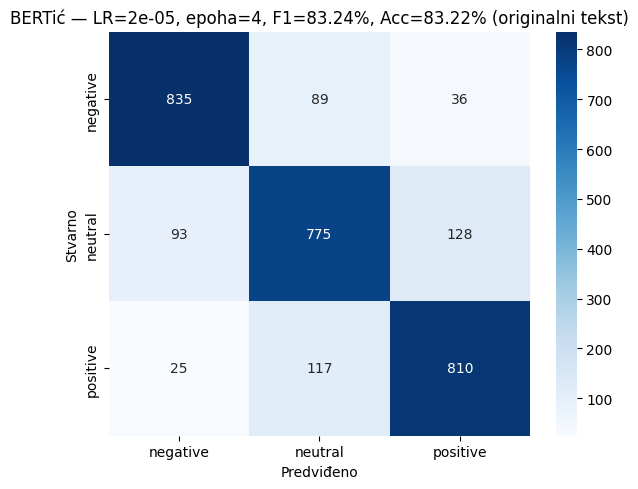

In [ ]:
rezultat_cased = train_and_evaluate_cv_best_epoch(lr=2e-5, lowercase=False)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

...

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 9/10: F1_macro po epohi = [np.float64(0.7983), np.float64(0.8628), np.float64(0.8495), np.float64(0.859), np.float64(0.8623)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 10/10: F1_macro po epohi = [np.float64(0.8032), np.float64(0.7919), np.float64(0.7981), np.float64(0.8383), np.float64(0.8207)]

=== Najbolja epoha: 5/5 ===
=== Krajnji rezultat (OOF, ceo dataset) ===
F1 macro: 0.8287
Accuracy: 0.8288

              precision    recall  f1-score   support

    negative       0.86      0.88      0.87       960
     neutral       0.79      0.77      0.78       996
    positive       0.83      0.84      0.84       952

    accuracy                           0.83      2908
   macro avg       0.83      0.83      0.83      2908
weighted avg       0.83      0.83      0.83      2908



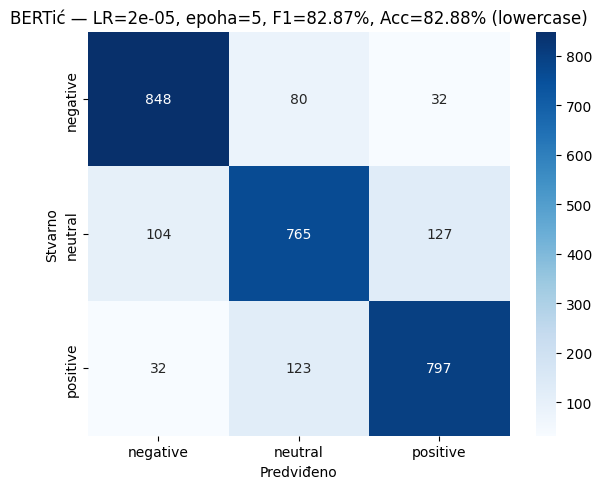

In [ ]:
rezultat_lower = train_and_evaluate_cv_best_epoch(lr=2e-5, lowercase=True)

ZA GRAF I LR

In [ ]:
def fine_tune_fold_epoch(lr, X_tr, y_tr, X_te, y_te, epochs=BROJ_EPOHA):
    """
    Trenira model na jednom foldu, evaluira POSLE SVAKE epohe.
    Vraca listu F1_macro vrednosti, po jedna za svaku epohu.
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID,
    ).to(device)

    train_loader = make_loader(X_tr, y_tr, shuffle=True)
    test_loader = make_loader(X_te, y_te, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.06 * total_steps), num_training_steps=total_steps,
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    per_epoch_f1 = []

    for epoch in range(1, epochs + 1):
        model.train()
        for ids, mask, yb in train_loader:
            ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss_fn(logits, yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in test_loader:
                logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
                preds.extend(logits.argmax(-1).cpu().numpy().tolist())

        f1_epoch = f1_score(y_te, preds, average="macro", zero_division=0)
        per_epoch_f1.append(f1_epoch)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return per_epoch_f1

In [ ]:
def cv_curve_epoch(lr, n_folds=BROJ_FOLDOVA, epochs=BROJ_EPOHA):
    """
    Sprovodi n_folds-slojnu CV za dati LR, prateci F1_macro posle svake
    epohe u svakom foldu. Vraca prosecan F1 po epohi (usrednjen preko foldova)
    i standardnu devijaciju.
    """
    set_seed(SEED)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    fold_f1 = np.zeros((n_folds, epochs))

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        f1s = fine_tune_fold_epoch(lr, X[train_idx], y[train_idx], X[test_idx], y[test_idx], epochs)
        fold_f1[fold_idx - 1] = f1s
        print(f"  [LR={lr}] Fold {fold_idx}/{n_folds}: F1 po epohi = "
              f"{[round(f, 4) for f in f1s]}")

    mean_f1 = fold_f1.mean(axis=0)
    std_f1 = fold_f1.std(axis=0)
    return mean_f1, std_f1, fold_f1

In [ ]:
LR_VREDNOSTI = [1e-5, 2e-5, 3e-5]
BOJE = {"1e-05": "#4c72b0", "2e-05": "#dd8452", "3e-05": "#55a868"}

rezultati_po_lr = {}

for lr in LR_VREDNOSTI:
    print(f"\n{'='*70}\nLR = {lr}\n{'='*70}")
    mean_f1, std_f1, fold_f1 = cv_curve_epoch(lr)
    rezultati_po_lr[lr] = {"mean": mean_f1, "std": std_f1, "fold_f1": fold_f1}
    print(f"\n  Prosecan F1 po epohi (LR={lr}): {[round(f, 4) for f in mean_f1]}")

# --- Grafik: sve tri krive na istom plotu ---
plt.figure(figsize=(8, 5.5))

for lr in LR_VREDNOSTI:
    mean_f1 = rezultati_po_lr[lr]["mean"]
    std_f1 = rezultati_po_lr[lr]["std"]
    epohe_x = np.arange(1, len(mean_f1) + 1)
    boja = BOJE[f"{lr:.0e}"]

    plt.errorbar(
        epohe_x, mean_f1, yerr=std_f1,
        marker="o", capsize=3, color=boja, label=f"LR={lr}",
    )

plt.xlabel("Broj epoha")
plt.ylabel("F1 macro (prosek preko 10 foldova)")
plt.title("BERTić — F1 macro po epohi, za različite learning rate vrednosti")
plt.xticks(epohe_x)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kriva_epoha_svi_lr.png", dpi=150)
plt.show()

# --- Najbolja epoha po LR ---
print("\n=== Najbolja epoha po LR vrednosti ===")
for lr in LR_VREDNOSTI:
    mean_f1 = rezultati_po_lr[lr]["mean"]
    std_f1 = rezultati_po_lr[lr]["std"]
    best_epoch = int(np.argmax(mean_f1)) + 1
    print(f"LR={lr}: najbolja epoha = {best_epoch}, "
          f"F1 = {mean_f1[best_epoch-1]:.4f} +/- {std_f1[best_epoch-1]:.4f}")


LR = 1e-05


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [LR=1e-05] Fold 1/10: F1 po epohi = [0.7405, 0.7984, 0.817, 0.8309, 0.8371]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [LR=2e-05] Fold 9/10: F1 po epohi = [0.8006, 0.8475, 0.8538, 0.879, 0.869]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
